# Customer Churn Prediction — Data Preprocessing & Final Validation
### Member 3: Data Preprocessing & Final Validation

**Objective:** Take the cleaned dataset (Member 2's output) and prepare it for
Exploratory Data Analysis (EDA) and Machine Learning modelling by:

1. Encoding categorical variables
2. Applying scaling / normalization
3. Checking the churn target class distribution
4. Producing the final preprocessed dataset
5. Validating the dataset is modelling-ready
6. Generating a data quality report
7. Documenting every decision made

**Input:** `Cleaned/customer_churn_cleaned.xlsx` (output of Member 2 — Data Cleaning)  
**Output:** `Dat_Preprocessing&Final_Validation/customer_churn_preprocessed.csv` (ready for EDA & Modelling)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load the Cleaned Dataset
This is the dataset handed off by Member 2 after cleaning (no missing values, no duplicates, correct dtypes).

In [2]:
df = pd.read_excel('../Cleaned/customer_churn_cleaned.xlsx')
print("Shape:", df.shape)
df.head()


Shape: (7043, 23)


,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Value,CLTV
0,90003,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,0,3,53.85,108.15,1,107.7
1,90005,Female,0,0,1,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,0,1,70.70,151.65,1,141.4
2,90006,Female,0,0,1,8,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,0,5,99.65,820.50,1,797.2
3,90010,Female,0,1,1,28,1,1,Fiber optic,0,0,1,1,1,1,Month-to-month,1,0,6,104.80,3046.05,1,2934.4
4,90015,Male,0,0,1,49,1,1,Fiber optic,0,1,1,0,1,1,Month-to-month,1,1,6,103.70,5036.30,1,5081.3


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Zip Code           7043 non-null   int64  
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   int64  
 7   Multiple Lines     7043 non-null   int64  
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   int64  
 10  Online Backup      7043 non-null   int64  
 11  Device Protection  7043 non-null   int64  
 12  Tech Support       7043 non-null   int64  
 13  Streaming TV       7043 non-null   int64  
 14  Streaming Movies   7043 non-null   int64  
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

## 2. Pre-Preprocessing Data Quality Snapshot
Quick sanity check to confirm we are starting from a genuinely clean dataset before
we transform anything.


In [4]:
quality_snapshot = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique()
})
quality_snapshot


,dtype,missing_values,missing_pct,unique_values
Zip Code,int64,0,0.0,1652
Gender,object,0,0.0,2
Senior Citizen,int64,0,0.0,2
Partner,int64,0,0.0,2
Dependents,int64,0,0.0,2
Tenure Months,int64,0,0.0,73
Phone Service,int64,0,0.0,2
Multiple Lines,int64,0,0.0,2
Internet Service,object,0,0.0,3
Online Security,int64,0,0.0,2


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values in dataset:", df.isnull().sum().sum())


Duplicate rows: 0
Total missing values in dataset: 0


## 3. Drop Non-Predictive Identifier Columns

`Zip Code` is a **geographic identifier**, not a meaningful numeric or ordinal feature.
It has 1,652 unique values (extremely high cardinality relative to 7,043 rows), and
treating it as a number would mislead a model into thinking e.g. zip code 90005 is
"greater than" 90003 in some meaningful way. It also isn't a clean categorical
candidate for one-hot encoding (far too many levels → curse of dimensionality).

**Decision:** Drop `Zip Code` from the modelling feature set. It is retained in a
separate lookup only if the business later wants geographic churn analysis, but it
does not enter the preprocessed modelling dataset.

*(Note: identifying/removing irrelevant columns is primarily a Member 2 task, but
this particular column only became a problem at the encoding/scaling stage, so the
decision and justification are documented here for transparency.)*


In [6]:
df_model = df.drop(columns=['Zip Code'])
df_model.shape


(7043, 22)

## 4. Encode Categorical Variables

The dataset already has most Yes/No fields pre-encoded as 0/1 by Member 2
(`Senior Citizen`, `Partner`, `Dependents`, `Phone Service`, `Multiple Lines`,
`Online Security`, `Online Backup`, `Device Protection`, `Tech Support`,
`Streaming TV`, `Streaming Movies`, `Paperless Billing`, `Payment Method`).

Three text/object columns remain and need explicit encoding:

| Column | Type | Cardinality | Encoding chosen | Reason |
|---|---|---|---|---|
| `Gender` | Binary categorical | 2 (Male/Female) | Label encoding (0/1) | Only two categories — one-hot would add a redundant column |
| `Internet Service` | Nominal categorical | 3 (DSL, Fiber optic, No) | One-Hot encoding | No natural order between categories |
| `Contract` | Nominal categorical | 3 (Month-to-month, One year, Two year) | One-Hot encoding | Although there's a loose "duration" order, treating it as unordered avoids forcing a false linear relationship; tree-based and linear models both handle one-hot cleanly |

`drop_first=True` is used for one-hot encoding to avoid the dummy variable trap
(multicollinearity) for linear models.


In [7]:
# Binary encode Gender: Female=0, Male=1
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])
print("Gender classes:", dict(zip(le.classes_, le.transform(le.classes_))))


Gender classes: {'Female': np.int64(0), 'Male': np.int64(1)}


In [8]:
# One-hot encode Internet Service and Contract
df_model = pd.get_dummies(df_model, columns=['Internet Service', 'Contract'],
                           drop_first=True)

# Convert the new boolean dummy columns to integers (0/1) for consistency
dummy_cols = [c for c in df_model.columns if c.startswith('Internet Service_') or c.startswith('Contract_')]
df_model[dummy_cols] = df_model[dummy_cols].astype(int)

print("New columns created:", dummy_cols)
df_model.head()


New columns created: ['Internet Service_Fiber optic', 'Internet Service_No', 'Contract_One year', 'Contract_Two year']


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Value,CLTV,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year
0,1,0,0,0,2,1,0,1,1,0,0,0,0,1,0,3,53.85,108.15,1,107.7,0,0,0,0
1,0,0,0,1,2,1,0,0,0,0,0,0,0,1,0,1,70.70,151.65,1,141.4,1,0,0,0
2,0,0,0,1,8,1,1,0,0,1,0,1,1,1,0,5,99.65,820.50,1,797.2,1,0,0,0
3,0,0,1,1,28,1,1,0,0,1,1,1,1,1,0,6,104.80,3046.05,1,2934.4,1,0,0,0
4,1,0,0,1,49,1,1,0,1,1,0,1,1,1,1,6,103.70,5036.30,1,5081.3,1,0,0,0


In [9]:
# Confirm every column is now numeric
df_model.dtypes


Gender                            int64
Senior Citizen                    int64
Partner                           int64
Dependents                        int64
Tenure Months                     int64
Phone Service                     int64
Multiple Lines                    int64
Online Security                   int64
Online Backup                     int64
Device Protection                 int64
Tech Support                      int64
Streaming TV                      int64
Streaming Movies                  int64
Paperless Billing                 int64
Payment Method                    int64
Total Frequency                   int64
Monthly Charges                 float64
Total Charges                   float64
Churn Value                       int64
CLTV                            float64
Internet Service_Fiber optic      int64
Internet Service_No               int64
Contract_One year                 int64
Contract_Two year                 int64
dtype: object

## 5. Feature Scaling / Normalization

Continuous numeric features have very different ranges (e.g. `Tenure Months`: 0–72,
`Total Charges`: ~19–8,700, `CLTV`: ~2,000–6,500). Distance-based and
gradient-based models (Logistic Regression, KNN, SVM, Neural Nets) are sensitive
to this — features on larger scales can dominate the objective function.

**Columns scaled:** `Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`,
`Total Frequency`

**Method:** `StandardScaler` (z-score standardization: mean = 0, std = 1). This is
preferred over Min-Max scaling here because these features contain some outliers
(e.g. `Total Charges`), and standardization is less distorted by them than min-max
scaling.

**Not scaled:** binary 0/1 columns and one-hot dummy columns — scaling binary flags
provides no benefit and reduces interpretability.

*Note: tree-based models (Random Forest, XGBoost) don't require scaling, but we
scale here so the dataset is ready for **any** model type Member 4 chooses.*


In [10]:
continuous_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Total Frequency']

scaler = StandardScaler()
df_model[continuous_cols] = scaler.fit_transform(df_model[continuous_cols])

df_model[continuous_cols].describe().round(2)


,Tenure Months,Monthly Charges,Total Charges,CLTV,Total Frequency
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.55,-1.01,-1.01,-1.63
25%,-0.95,-0.97,-0.83,-0.83,-1.15
50%,-0.14,0.19,-0.39,-0.39,-0.18
75%,0.92,0.83,0.66,0.67,0.79
max,1.61,1.79,2.83,2.77,2.25


## 6. Churn Target Class Distribution

Checking class balance in `Churn Value` (0 = retained, 1 = churned) matters because
a strongly imbalanced target can make a model look "accurate" while actually just
predicting the majority class every time.


Churn Value
0    5174
1    1869
Name: count, dtype: int64

Churn Value
0    73.46
1    26.54
Name: proportion, dtype: float64


C:\Users\chand\AppData\Local\Temp\ipykernel_5136\4168498159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Value', data=df_model, ax=ax[0], palette=['#4C72B0', '#DD8452'])
C:\Users\chand\AppData\Local\Temp\ipykernel_5136\4168498159.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Retained (0)', 'Churned (1)'])


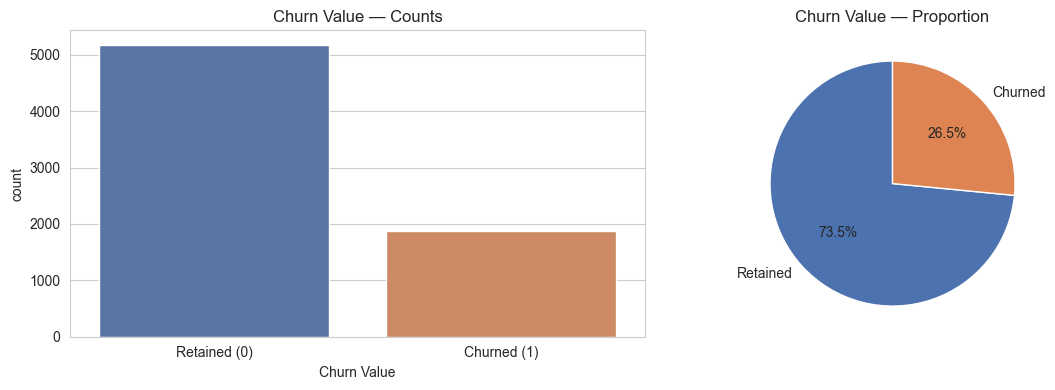

In [11]:
churn_counts = df_model['Churn Value'].value_counts()
churn_pct = df_model['Churn Value'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Churn Value', data=df_model, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title('Churn Value — Counts')
ax[0].set_xticklabels(['Retained (0)', 'Churned (1)'])

ax[1].pie(churn_pct, labels=['Retained', 'Churned'], autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title('Churn Value — Proportion')
plt.tight_layout()
plt.savefig('../figures/churn_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** The dataset is **imbalanced** — roughly 73.5% retained vs. 26.5%
churned (about a 2.8:1 ratio).

**Implication for Member 4 (Modelling):** This isn't corrected at the preprocessing
stage (resampling should happen *after* the train/test split to avoid data leakage
into the test set). It's flagged here so the modelling step accounts for it, e.g. via:
- `class_weight='balanced'` in scikit-learn models
- SMOTE / oversampling applied only to the training fold
- Evaluating with Precision, Recall, F1, and ROC-AUC rather than plain Accuracy


## 7. Quick Correlation Sanity Check

A fast check for any feature suspiciously perfectly correlated with the target,
which would indicate leftover data leakage that should have been caught in
cleaning but is worth re-confirming after encoding.


In [12]:
corr_with_target = df_model.corr(numeric_only=True)['Churn Value'].sort_values(ascending=False)
corr_with_target


Churn Value                     1.000000
Internet Service_Fiber optic    0.308020
Monthly Charges                 0.193356
Paperless Billing               0.191825
Senior Citizen                  0.150889
Streaming TV                    0.063228
Streaming Movies                0.061382
Multiple Lines                  0.040102
Phone Service                   0.011942
Gender                         -0.008612
Device Protection              -0.066160
Total Frequency                -0.067264
Online Backup                  -0.082255
Partner                        -0.150448
Tech Support                   -0.164674
Online Security                -0.171226
Contract_One year              -0.177820
Total Charges                  -0.198324
CLTV                           -0.198514
Payment Method                 -0.209902
Internet Service_No            -0.227890
Dependents                     -0.248542
Contract_Two year              -0.302253
Tenure Months                  -0.352229
Name: Churn Valu

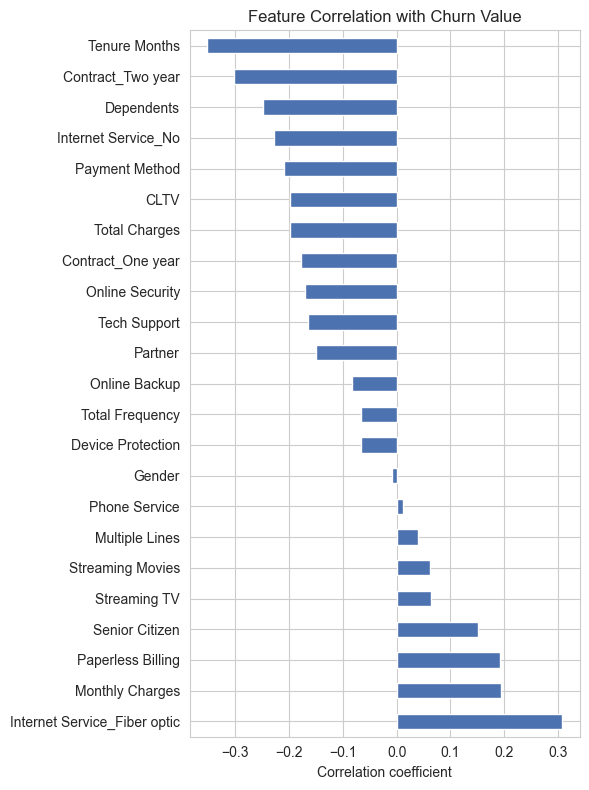

In [13]:
plt.figure(figsize=(6, 8))
corr_with_target.drop('Churn Value').plot(kind='barh', color='#4C72B0')
plt.title('Feature Correlation with Churn Value')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('../figures/feature_correlation_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()


No feature shows near-1.0 correlation with `Churn Value`, so there's no evidence
of residual data leakage at this stage.


## 8. Final Validation — Is the Dataset Modelling-Ready?

A checklist confirming the dataset meets the requirements for EDA and ML modelling.

**A note on duplicates:** this dataset has no customer ID column at all — every
row is identified only by its feature values. After dropping `Zip Code`, a small
number of rows (customers) become identical across every *remaining* column.


In [14]:
post_drop_dupes = df_model.duplicated().sum()
print(f"Rows identical on all features *after* dropping Zip Code: {post_drop_dupes}")
print(f"Rows identical on all features *including* Zip Code (i.e. true exact duplicates): {df.duplicated().sum()}")


Rows identical on all features *after* dropping Zip Code: 26
Rows identical on all features *including* Zip Code (i.e. true exact duplicates): 0


**Interpretation:** With `df.duplicated().sum() == 0` (checked already by Member 2
on the raw/cleaned data, and reconfirmed above using the original data including
`Zip Code`), there are **no true duplicate customer records**. The handful of rows
that look identical once `Zip Code` is removed are simply different customers who
happen to share the same demographic and service profile — an expected coincidence
given how many binary/low-cardinality categorical columns this dataset has, and
unavoidable without a unique customer ID. These rows are genuine, distinct
observations and are **kept** in the dataset; they are not dropped.

This is why the validation check below tests for duplicates using the **original
cleaned data (with Zip Code)** — the true measure of record uniqueness — rather
than the post-encoding modelling frame.


In [15]:
checks = {
    "No missing values": df_model.isnull().sum().sum() == 0,
    "No true duplicate records (checked pre-drop, incl. Zip Code)": df.duplicated().sum() == 0,
    "All columns numeric": all(df_model.dtypes != 'object'),
    "Target column present ('Churn Value')": 'Churn Value' in df_model.columns,
    "Target is binary (0/1)": set(df_model['Churn Value'].unique()) == {0, 1},
    "No identifier columns left (e.g. Zip Code)": 'Zip Code' not in df_model.columns,
    "Row count unchanged from cleaned input": len(df_model) == len(df),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} -- {check}")

assert all(checks.values()), "Dataset failed validation — review before handing off to Member 4"
print("\nAll validation checks passed. Dataset is ready for EDA & Modelling.")


PASS -- No missing values
PASS -- No true duplicate records (checked pre-drop, incl. Zip Code)
PASS -- All columns numeric
PASS -- Target column present ('Churn Value')
PASS -- Target is binary (0/1)
PASS -- No identifier columns left (e.g. Zip Code)
PASS -- Row count unchanged from cleaned input

All validation checks passed. Dataset is ready for EDA & Modelling.


In [16]:
print("Final shape:", df_model.shape)
print("\nFinal columns:")
for c in df_model.columns:
    print(" -", c)


Final shape: (7043, 24)

Final columns:
 - Gender
 - Senior Citizen
 - Partner
 - Dependents
 - Tenure Months
 - Phone Service
 - Multiple Lines
 - Online Security
 - Online Backup
 - Device Protection
 - Tech Support
 - Streaming TV
 - Streaming Movies
 - Paperless Billing
 - Payment Method
 - Total Frequency
 - Monthly Charges
 - Total Charges
 - Churn Value
 - CLTV
 - Internet Service_Fiber optic
 - Internet Service_No
 - Contract_One year
 - Contract_Two year


## 9. Data Quality Report (Summary)

A compact, shareable summary of the preprocessing stage for the project report.


In [17]:
report = {
    "Input rows": len(df),
    "Input columns": df.shape[1],
    "Output rows": len(df_model),
    "Output columns": df_model.shape[1],
    "Columns dropped": "Zip Code (high-cardinality identifier)",
    "Columns label-encoded": "Gender",
    "Columns one-hot encoded": "Internet Service, Contract",
    "Columns scaled (StandardScaler)": ", ".join(continuous_cols),
    "Missing values (final)": int(df_model.isnull().sum().sum()),
    "Duplicate rows (final)": int(df_model.duplicated().sum()),
    "Churn rate (target=1)": f"{churn_pct[1]:.2f}%",
    "Class balance": f"{churn_pct[0]:.1f}% retained / {churn_pct[1]:.1f}% churned (imbalanced)",
}

report_df = pd.DataFrame(list(report.items()), columns=['Metric', 'Value'])
report_df


,Metric,Value
0,Input rows,7043
1,Input columns,23
2,Output rows,7043
3,Output columns,24
4,Columns dropped,Zip Code (high-cardinality identifier)
5,Columns label-encoded,Gender
6,Columns one-hot encoded,"Internet Service, Contract"
7,Columns scaled (StandardScaler),"Tenure Months, Monthly Charges, Total Charges,..."
8,Missing values (final),0
9,Duplicate rows (final),26


In [18]:
report_df.to_csv('../Data_Preprocessing&Final_Validation/data_quality_report.csv', index=False)
print("Saved: data/data_quality_report.csv")


Saved: data/data_quality_report.csv


## 10. Save the Final Preprocessed Dataset

This CSV is the handoff artifact for Member 4 (EDA & Modelling).


In [19]:
df_model.to_csv('../Data_Preprocessing&Final_Validation/customer_churn_preprocessed.csv', index=False)
print("Saved: data/customer_churn_preprocessed.csv")
print("Final shape:", df_model.shape)


Saved: data/customer_churn_preprocessed.csv
Final shape: (7043, 24)


## 11. Summary of Preprocessing Decisions (Documentation)

| Step | Decision | Justification |
|---|---|---|
| Identifier removal | Dropped `Zip Code` | High-cardinality (1,652 unique values), not ordinal, unsuitable for direct modelling |
| `Gender` | Label encoded (Female=0, Male=1) | Binary category, one-hot unnecessary |
| `Internet Service` | One-hot encoded, `drop_first=True` | Nominal category, 3 levels, no natural order |
| `Contract` | One-hot encoded, `drop_first=True` | Nominal category, 3 levels, avoids forcing false ordinal relationship |
| `Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`, `Total Frequency` | StandardScaler | Wide value ranges; standardization needed for distance/gradient-based models, robust-ish to outliers |
| Binary flag columns (`Partner`, `Online Security`, etc.) | Left as-is (0/1) | Already numeric and correctly scaled by nature (0/1) |
| Target (`Churn Value`) | Left as-is, distribution checked | Found imbalanced (~26.5% churn) — flagged for Member 4 to handle at modelling stage |
| Duplicate check | Verified on original data incl. `Zip Code` (0 true duplicates) rather than post-encoding frame | Dataset has no customer ID column; 26 rows look identical once `Zip Code` is dropped but are genuinely distinct customers with matching profiles, not duplicate records |

**Deliverables produced by this notebook:**
- `Data_Preprocessing&Final_Validation/customer_churn_preprocessed.csv` — final preprocessed dataset
- `Data_Preprocessing&Final_Validation/data_quality_report.csv` — data quality report
- `figures/churn_class_distribution.png` — churn balance chart
- `figures/feature_correlation_with_churn.png` — correlation chart
- This notebook itself, serving as the preprocessing documentation

**Next step:** Handoff to EDA & Modelling phase.
